# Spotify EDA : Data Cleaning & Overview

This notebook covers:
- Loading and inspecting the dataset
- Dropping unnecessary columns
- Handling missing values
- Identifying and resolving duplicate track IDs
- Feature engineering: duration in minutes + popularity tiers

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:
df = pd.read_csv('dataset.csv')
print(f'Shape:{df.shape[0]:,}rows×{df.shape[1]}columns')
df.head()

Shape:114,000rows×21columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.dtypes.to_frame('dtype').assign(
    non_null=df.notnull().sum(),
    null_count=df.isnull().sum(),
    unique_values=df.nunique()
)

,dtype,non_null,null_count,unique_values
Unnamed: 0,int64,114000,0,114000
track_id,object,114000,0,89741
artists,object,113999,1,31437
album_name,object,113999,1,46589
track_name,object,113999,1,73608
popularity,int64,114000,0,101
duration_ms,int64,114000,0,50697
explicit,bool,114000,0,2
danceability,float64,114000,0,1174
energy,float64,114000,0,2083


In [7]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.columns.tolist())

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [9]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing>0]
print(missing)
df[df.isnull().any(axis=1)]

artists       1
album_name    1
track_name    1
dtype: int64


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [12]:
# drop missing value columns
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)

In [16]:
total_tracks     = len(df)
unique_track_ids = df['track_id'].nunique()
duplicate_rows   = total_tracks - unique_track_ids

print(f'Total rows        : {total_tracks:,}')
print(f'Unique track IDs  : {unique_track_ids:,}')
print(f'Duplicate rows    : {duplicate_rows:,}')

# Example: same song appearing in multiple genres
dup_example = df[df.duplicated(subset='track_id', keep=False)].sort_values('track_id')

dup_example[['track_name','artists','track_genre']].head(6)

Total rows        : 113,999
Unique track IDs  : 89,740
Duplicate rows    : 24,259


,track_name,artists,track_genre
15028,Better,Pink Sweat$;Kirby,chill
103211,Better,Pink Sweat$;Kirby,soul
85578,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
91801,Mr. Brightside,The Killers,rock
3257,Mr. Brightside,The Killers,alternative


Tracks by number of genre appearances:
track_genre
1    73099
2    11712
3     2984
4     1372
5      431
6      117
7       22
8        2
9        1
Name: count, dtype: int64


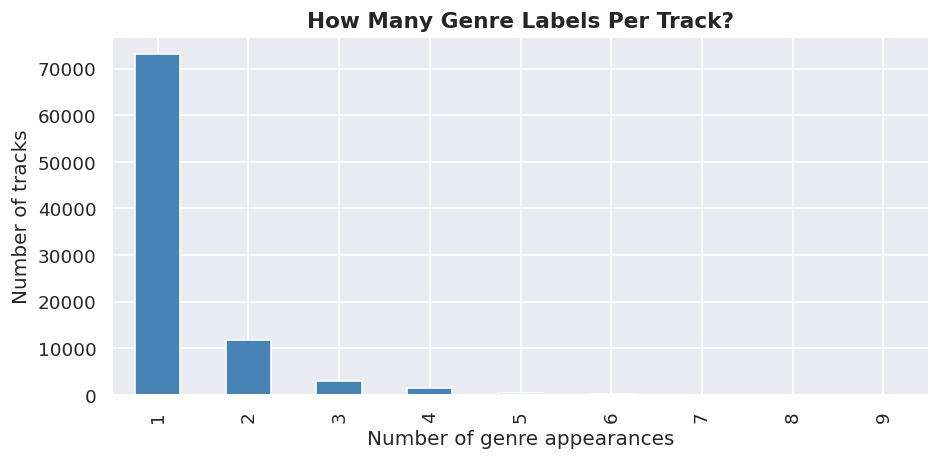

In [19]:
# Distribution: how many genres does one track appear in?
genre_counts = df.groupby('track_id')['track_genre'].count()

print('Tracks by number of genre appearances:')
print(genre_counts.value_counts().sort_index().head(10))

fig, ax = plt.subplots(figsize=(8, 4))
genre_counts.value_counts().sort_index().head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('How Many Genre Labels Per Track?', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of genre appearances')
ax.set_ylabel('Number of tracks')
plt.tight_layout()
plt.show()

In [21]:
#create a deduplicated version (one row per track, highest popularity kept)
df_unique = (
    df.sort_values('popularity', ascending=False)
      .drop_duplicates(subset='track_id', keep='first')
      .reset_index(drop=True)
)

print(f'Full dataset (multi-genre): {len(df):,} rows')
print(f'Deduplicated dataset      : {len(df_unique):,} rows')


Full dataset (multi-genre): 113,999 rows
Deduplicated dataset      : 89,740 rows


In [27]:
# --- A. Convert duration_ms to minutes ---
for frame in [df, df_unique]:
    frame['duration_min'] = (frame['duration_ms'] / 60000).round(2)

In [28]:
# --- B. Bin popularity into tiers ---
bins=[-1, 20, 45, 65, 100]
labels=['Low (0–20)', 'Medium (21–45)', 'High (46–65)', 'Viral (66–100)']

for frame in [df, df_unique]:
    frame['popularity_tier'] = pd.cut(frame['popularity'], bins=bins, labels=labels)

print('Popularity tier distribution (duplicated tracks):')
print(df_unique['popularity_tier'].value_counts().sort_index())

Popularity tier distribution (duplicated tracks):
popularity_tier
Low (0–20)        25081
Medium (21–45)    38029
High (46–65)      21520
Viral (66–100)     5110
Name: count, dtype: int64


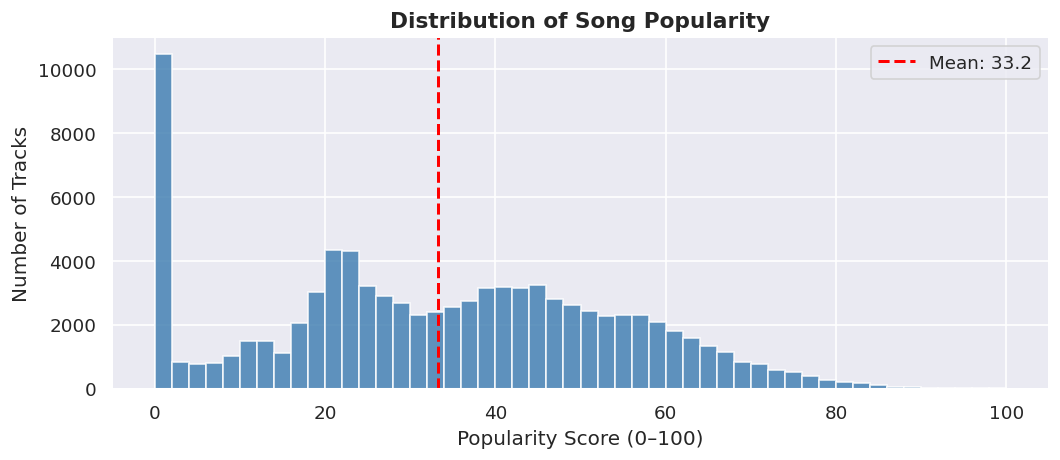

count    89740.00
mean        33.21
std         20.57
min          0.00
25%         19.00
50%         33.00
75%         49.00
max        100.00
Name: popularity, dtype: float64


In [29]:
# popularity distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_unique['popularity'],bins=50,color='steelblue',edgecolor='white',alpha=0.85)

mean_pop = df_unique['popularity'].mean()
ax.axvline(mean_pop, color='red', linestyle='--', linewidth=1.8, label=f'Mean: {mean_pop:.1f}')
ax.set_title('Distribution of Song Popularity', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Number of Tracks')
ax.legend()
plt.tight_layout()
plt.show()
print(df_unique['popularity'].describe().round(2))

# Spotify EDA : What Makes a Song Popular?

This notebook explores:
- Correlation heatmap of all audio features vs popularity
- Scatter plots of key features vs popularity
- Popularity by explicit content (boxplot)
- Top 20 most popular songs and their audio profiles

In [30]:
# Audio feature columns we'll analyse throughout this module
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_min'
]

print('Audio features in scope:', AUDIO_FEATURES)

Audio features in scope: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']


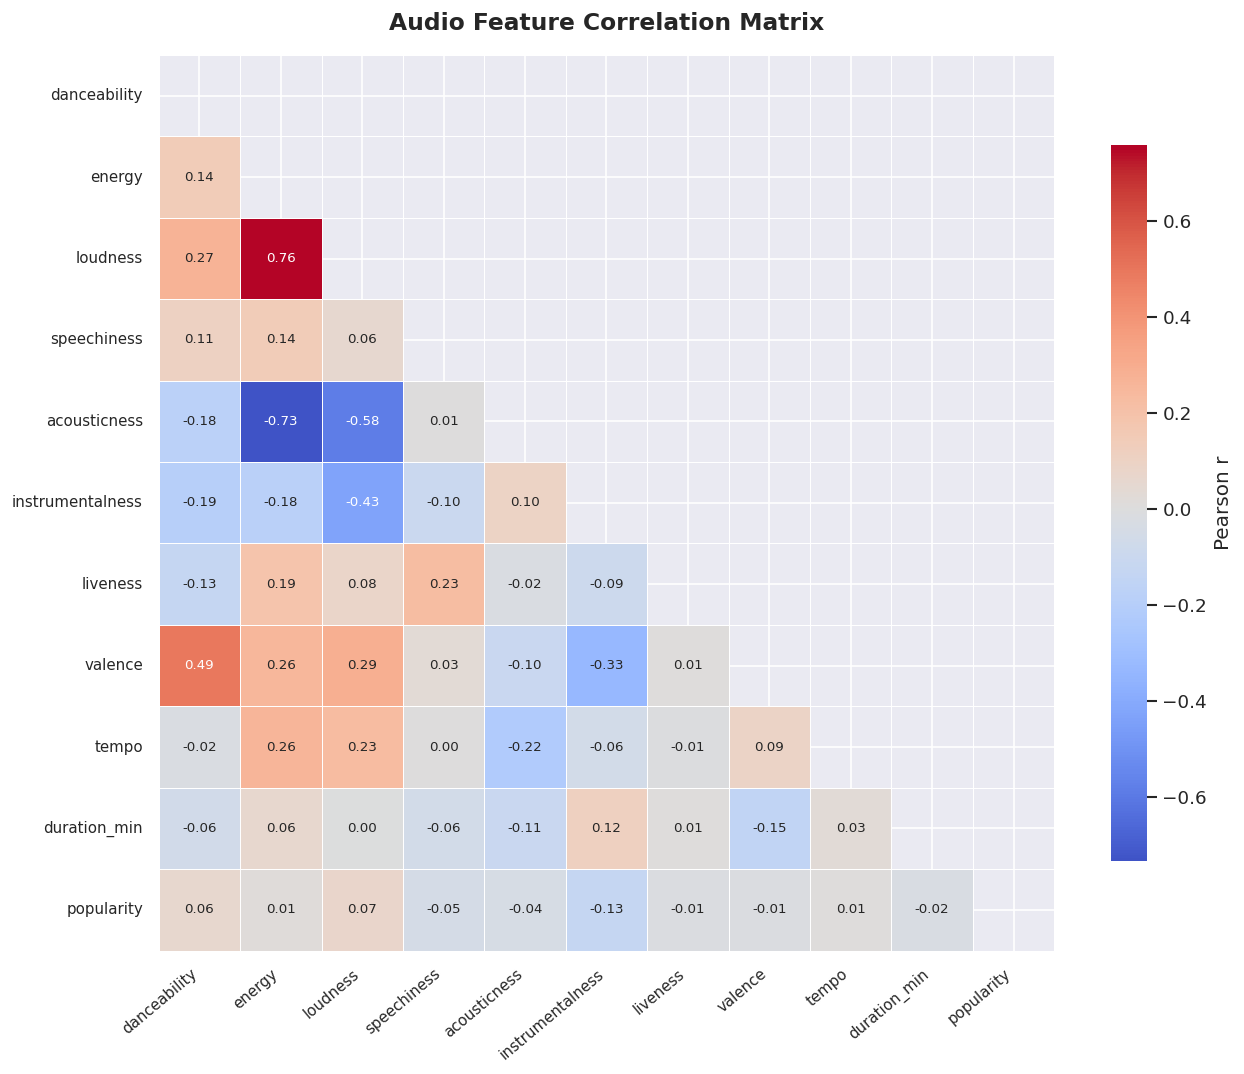

In [31]:
# Full correlation matrix across audio features + popularity
corr_cols = AUDIO_FEATURES + ['popularity']
corr_matrix = df_unique[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Audio Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# How many explicit vs non-explicit tracks?
explicit_counts = df_unique['explicit'].value_counts()
print('Explicit track counts:')
print(explicit_counts)
print(f'\nExplicit share: {explicit_counts[True] / len(df_unique) * 100:.2f}%')

Explicit track counts:
explicit
False    82036
True      7704
Name: count, dtype: int64

Explicit share: 8.58%


Text(0, 0.5, 'Popularity Score')

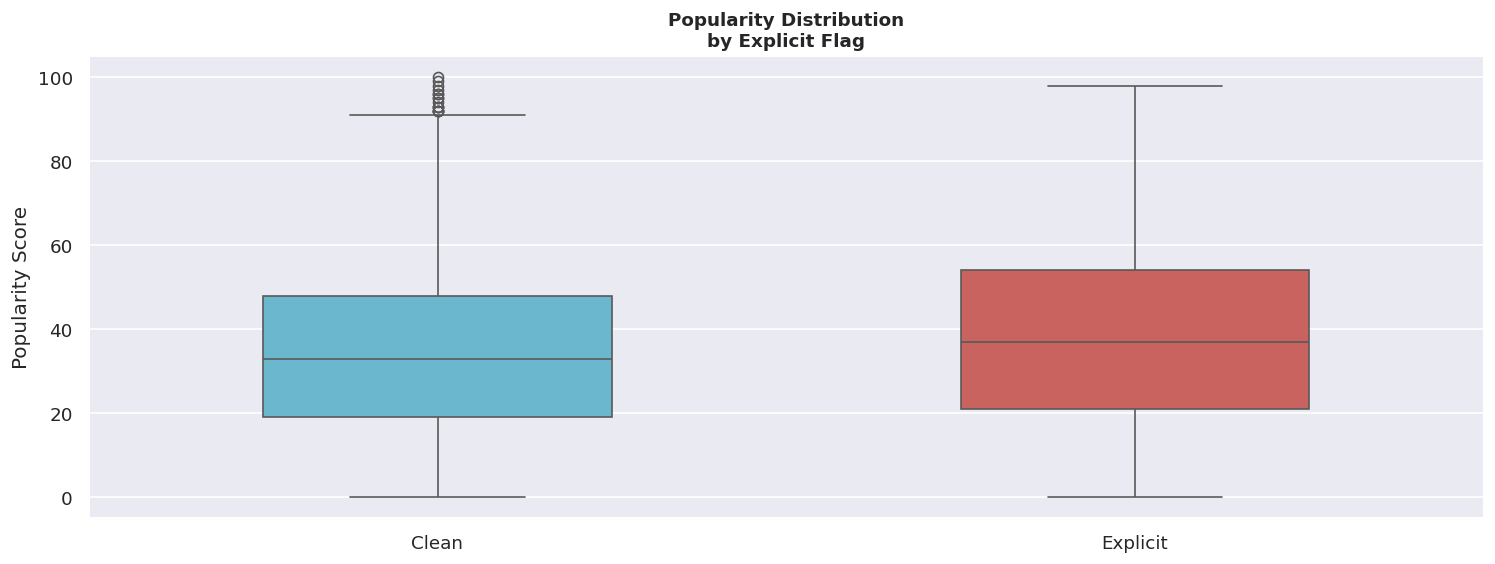

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
exp_labels = {False: 'Clean', True: 'Explicit'}
palettes = {False: '#5bc0de', True: '#d9534f'}

sns.boxplot(
    data=df_unique, 
    x='explicit', 
    y='popularity',
    hue='explicit',
    legend=False,
    palette=palettes, 
    width=0.5, 
    ax=ax,
    order=[False, True]
)

ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Clean', 'Explicit'])
ax.set_title('Popularity Distribution\nby Explicit Flag', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Popularity Score')

In [46]:
top20 = df_unique.nlargest(20, 'popularity')[['track_name', 'artists', 'track_genre','popularity', 'explicit']+AUDIO_FEATURES].reset_index(drop=True)
top20.index += 1
print('Top 20 Most Popular Tracks:')
top20[['track_name', 'artists', 'track_genre', 'popularity', 'explicit']]

Top 20 Most Popular Tracks:


,track_name,artists,track_genre,popularity,explicit
1,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,False
2,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99,False
3,La Bachata,Manuel Turizo,reggae,98,False
4,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98,True
5,Tití Me Preguntó,Bad Bunny,latino,97,False
6,Me Porto Bonito,Bad Bunny;Chencho Corleone,reggaeton,97,True
7,Efecto,Bad Bunny,latin,96,False
8,Under The Influence,Chris Brown,pop,96,True
9,I Ain't Worried,OneRepublic,piano,96,False
10,Ojitos Lindos,Bad Bunny;Bomba Estéreo,latino,95,False


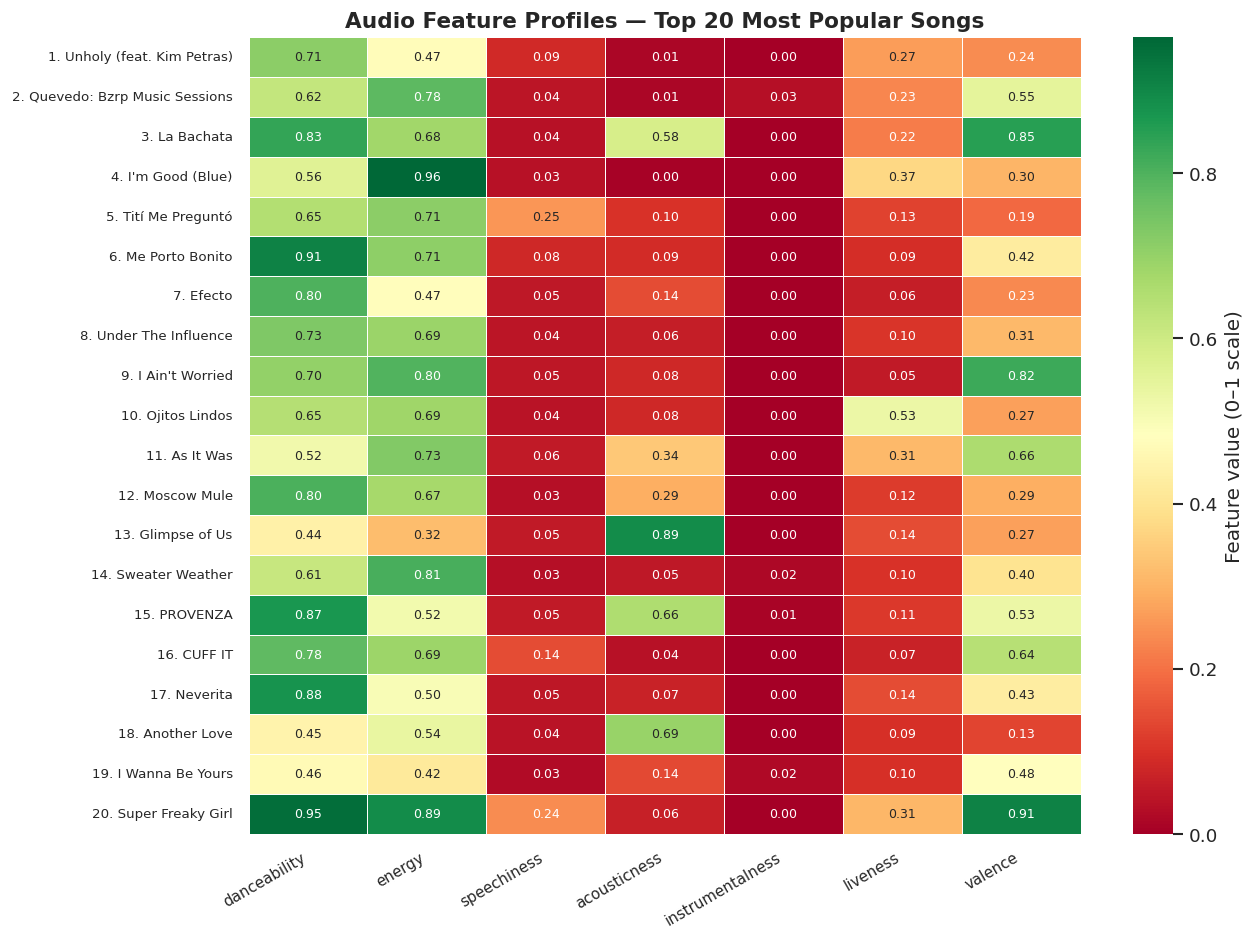

In [47]:
# Heatmap of audio features for the top 20 songs
# Normalise features to 0-1 for comparable colour scale
radar_features = ['danceability', 'energy', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence']

top20_heat = top20[radar_features].copy()
top20_heat.index = [f"{i}. {r['track_name'][:28]}" for i, r in top20.iterrows()]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    top20_heat, annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.4, ax=ax,
    annot_kws={'size': 7.5},
    cbar_kws={'label': 'Feature value (0–1 scale)'}
)
ax.set_title('Audio Feature Profiles — Top 20 Most Popular Songs', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()